# Analysis of title grouping using tSNE

In [1]:
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt
import numpy as np
import random

### Preprocess title embeddings for tSNE

In [2]:
df_emb = pd.read_csv('../../Amazon_Sports_and_Outdoors/Amazon_Sports_and_Outdoors(msmarco-distilbert-base-dot-prod-v3).title', sep='\t')
df_emb.head(5)

,ent_id:token,ent_emb:float_seq
0,884509,0.11831325 0.09197483 0.05229783 0.11115509 0....
1,561856,0.17305994 -0.062206417 -0.046176672 0.0319943...
2,239749,-0.052958608 0.17778905 0.124999404 0.0699659 ...
3,55030,0.043756247 0.06027646 0.036592722 0.13502795 ...
4,1277121,0.05444306 0.10098225 0.124993265 0.08889228 0...


In [10]:
df_emb.rename(columns={"ent_emb:float_seq": "emb", "ent_id:token": "id"}, inplace=True)
df_emb["emb"] = df_emb["emb"].apply(lambda x: np.fromstring(x, dtype=np.float32, sep=' '))
df_emb.head(5)

,id,emb
0,884509,"[0.11831325, 0.09197483, 0.05229783, 0.1111550..."
1,561856,"[0.17305994, -0.062206417, -0.046176672, 0.031..."
2,239749,"[-0.052958608, 0.17778905, 0.124999404, 0.0699..."
3,55030,"[0.043756247, 0.06027646, 0.036592722, 0.13502..."
4,1277121,"[0.05444306, 0.10098225, 0.124993265, 0.088892..."


In [3]:
df_cat = pd.read_csv('../../Amazon_Sports_and_Outdoors/Amazon_Sports_and_Outdoors.item', sep='\t')
df_cat.head(5)

,item_id:token,title:token,price:float,brand:token,categories:token_seq,sales_type:token,sales_rank:float
0,884509,Sure-Grip Zombie Wheels Low 59mm 4 Pack,55.00,Sure-Grip,"'Sports & Outdoors', 'Sports', 'Skates, Skateb...",Sports & Outdoors,295175.0
1,561856,USGI Wet Weather Bag (Fоur Paсk),NaN,USGI,"'Sports & Outdoors', 'Sports', 'Boating & Sail...",Sports & Outdoors,962400.0
2,239749,NHL San Jose Sharks Team Logo Post Earrings,18.99,Aminco,"'Sports & Outdoors', 'Fan Shop', 'Jewelry & Wa...",Sports & Outdoors,721263.0
3,55030,Bont Skates - Prostar Purple Suede Professiona...,209.00,Bont,"'Sports & Outdoors', 'Sports', 'Skates, Skateb...",Sports & Outdoors,213685.0
4,1277121,Team Golf Alamaba Crimson Tide Embroidered Tow...,NaN,Team Golf,"'Sports & Outdoors', 'Fan Shop', 'Sports Equip...",Sports & Outdoors,1621084.0


In [4]:
df_cat = df_cat.rename(columns={"categories:token_seq": "cat", "item_id:token": "id"})
df_cat['cat'] = df_cat['cat'].apply(lambda x: [entry for entry in str(x).split(',')])
df_cat.drop(columns=['price:float', 'title:token', 'sales_rank:float', 'sales_type:token'], inplace=True)
df_cat.head(5)

,id,brand:token,cat
0,884509,Sure-Grip,"['Sports & Outdoors', 'Sports', 'Skates, Sk..."
1,561856,USGI,"['Sports & Outdoors', 'Sports', 'Boating & S..."
2,239749,Aminco,"['Sports & Outdoors', 'Fan Shop', 'Jewelry &..."
3,55030,Bont,"['Sports & Outdoors', 'Sports', 'Skates, Sk..."
4,1277121,Team Golf,"['Sports & Outdoors', 'Fan Shop', 'Sports Eq..."


In [5]:
categories_2d = df_cat['cat'].tolist()

categories = []
for entry in categories_2d:
    for cat in entry:
        categories.append(cat)

categories = set(categories)

In [6]:
import random

colour_dict = {cat: random.randint(0, 255) for cat in categories}

def rgb_mean(cat_list):
    rbg = 0
    for x in cat_list:
        rbg += colour_dict[x]

    return rbg / len(cat_list)

In [7]:
df_cat['colour'] = df_cat['cat'].apply(rgb_mean)
df_cat.head(5)

,id,brand:token,cat,colour
0,884509,Sure-Grip,"['Sports & Outdoors', 'Sports', 'Skates, Sk...",115.285714
1,561856,USGI,"['Sports & Outdoors', 'Sports', 'Boating & S...",129.800000
2,239749,Aminco,"['Sports & Outdoors', 'Fan Shop', 'Jewelry &...",128.000000
3,55030,Bont,"['Sports & Outdoors', 'Sports', 'Skates, Sk...",134.857143
4,1277121,Team Golf,"['Sports & Outdoors', 'Fan Shop', 'Sports Eq...",161.200000


In [ ]:
SAMPLE_SIZE = 10000

emb_series = df_emb[df_emb['emb'].notnull()]['emb']

X = np.vstack(emb_series.values)

rand_ind = np.random.choice(range(len(X)), SAMPLE_SIZE, replace=False)
X = X[rand_ind]

for perplexity in range(1, 100):
    X_emb = TSNE(n_components=2, perplexity=perplexity).fit_transform(X)
    plt.title(f't-SNE visualization perplexity: {perplexity}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.scatter(X_emb[:,0], X_emb[:,1], c=df_cat['colour'][rand_ind])
    plt.show()

### tSNE visualization

In [ ]:
SAMPLE_SIZE = 10000

emb_series = df_emb[df_emb['emb'].notnull()]['emb']

X = np.vstack(emb_series.values)

rand_ind = np.random.choice(range(len(X)), SAMPLE_SIZE, replace=False)
X = X[rand_ind]

X_emb = TSNE(n_components=2, perplexity=300).fit_transform(X)

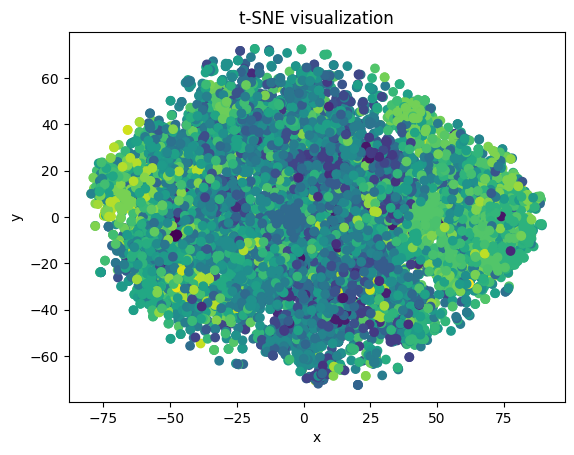

In [18]:
plt.title('t-SNE visualization')
plt.xlabel('x')
plt.ylabel('y')
plt.scatter(X_emb[:,0], X_emb[:,1], c=df_cat['colour'][rand_ind])
plt.show()